Mechanistic Hyperbolic Radial ODE

In [ ]:
import numpy as np
import pandas as pd
import torch
import geoopt
import statsmodels.api as sm

# ---------------------------------------
# You must already have:
# prev_z per stage from incremental training
# If not, rerun aligned hyperbolic embedding across stages
# ---------------------------------------

# We will recompute embeddings incrementally

manifold = geoopt.PoincareBall(c=1.0)

def get_radius(z):
    return torch.norm(z, dim=1).detach().numpy()

radial_data = []

prev_z = None
prev_nodes = None
prev_G = None

for stage in range(1,9):

    print(f"Processing Stage {stage}")

    # Load graph
    G = build_graph(stage)   # uses your previous function
    nodes = list(G.nodes())
    A = graph_to_adj(G, nodes)

    if prev_z is None:
        z = train_hyperbolic(A, manifold)
    else:
        # Align nodes
        common_nodes = list(set(prev_nodes) & set(nodes))
        idx_prev = [prev_nodes.index(n) for n in common_nodes]
        idx_curr = [nodes.index(n) for n in common_nodes]

        z_init = torch.randn(len(nodes), 2)*0.01
        z_init[idx_curr] = prev_z[idx_prev]

        z = train_hyperbolic(A, manifold, z_init=z_init)

        # ---- Collect radial dynamics ----

        r_prev = get_radius(prev_z[idx_prev])
        r_curr = get_radius(z[idx_curr])

        dr = r_curr - r_prev

        degrees_prev = np.array([prev_G.degree(n) for n in common_nodes])
        log_degree = np.log(degrees_prev + 1)

        for i in range(len(common_nodes)):
            radial_data.append({
                "stage": stage-1,
                "r_prev": r_prev[i],
                "dr": dr[i],
                "log_degree": log_degree[i]
            })

    prev_z = z
    prev_nodes = nodes
    prev_G = G

# ---------------------------------------
# Fit Radial ODE Parameters
# ---------------------------------------

df = pd.DataFrame(radial_data)

X = df[["r_prev", "log_degree"]]
X = sm.add_constant(X)

y = df["dr"]

model = sm.OLS(y, X)
result = model.fit()

print(result.summary())

Processing Stage 1
Processing Stage 2
Processing Stage 3
Processing Stage 4
Processing Stage 5
Processing Stage 6
Processing Stage 7
Processing Stage 8
                            OLS Regression Results                            
Dep. Variable:                     dr   R-squared:                       0.320
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     332.8
Date:                Mon, 02 Mar 2026   Prob (F-statistic):          3.29e-119
Time:                        12:19:49   Log-Likelihood:                 802.33
No. Observations:                1419   AIC:                            -1599.
Df Residuals:                    1416   BIC:                            -1583.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|    

Simulating the mechanistic radial ODE forward and compare it to actual developmental trajectories

In [ ]:
import numpy as np
import pandas as pd
import torch

# Use fitted parameters from regression
a = 0.7149
b = 0.5260
c = 0.1075   # NOTE: sign handled below

manifold = geoopt.PoincareBall(c=1.0)

def get_radius(z):
    return torch.norm(z, dim=1).detach().numpy()

# -----------------------------------------
# Collect actual radii across stages
# -----------------------------------------

actual_radii = {}
degree_data = {}

prev_z = None
prev_nodes = None

for stage in range(1,9):

    G = build_graph(stage)
    nodes = list(G.nodes())
    A = graph_to_adj(G, nodes)

    if prev_z is None:
        z = train_hyperbolic(A, manifold)
    else:
        common_nodes = list(set(prev_nodes) & set(nodes))
        idx_prev = [prev_nodes.index(n) for n in common_nodes]
        idx_curr = [nodes.index(n) for n in common_nodes]

        z_init = torch.randn(len(nodes), 2)*0.01
        z_init[idx_curr] = prev_z[idx_prev]

        z = train_hyperbolic(A, manifold, z_init=z_init)

    r = get_radius(z)

    actual_radii[stage] = dict(zip(nodes, r))
    degree_data[stage] = dict(G.degree())

    prev_z = z
    prev_nodes = nodes

# -----------------------------------------
# Simulate radial dynamics forward
# -----------------------------------------

predicted_radii = {}
predicted_radii[1] = actual_radii[1].copy()

for stage in range(1,8):

    predicted_radii[stage+1] = {}

    for node in predicted_radii[stage].keys():

        # Only simulate if node exists in next stage
        if node in actual_radii[stage+1]:

            r_prev = predicted_radii[stage][node]
            k_prev = degree_data[stage][node]

            dr = a - b*r_prev - c*np.log(k_prev + 1)

            predicted_radii[stage+1][node] = r_prev + dr

# -----------------------------------------
# Evaluate prediction quality
# -----------------------------------------

all_actual = []
all_predicted = []

for stage in range(2,9):

    for node in predicted_radii[stage].keys():

        all_actual.append(actual_radii[stage][node])
        all_predicted.append(predicted_radii[stage][node])

all_actual = np.array(all_actual)
all_predicted = np.array(all_predicted)

ss_res = np.sum((all_actual - all_predicted)**2)
ss_tot = np.sum((all_actual - np.mean(all_actual))**2)
r2 = 1 - ss_res/ss_tot

print("Radial ODE Simulation R^2:", r2)

Radial ODE Simulation R^2: 0.35259211062810847


In [ ]:
import numpy as np
import pandas as pd

stage_r2_results = []

for stage in range(1,8):

    actual_vals = []
    predicted_vals = []

    for node in predicted_radii[stage+1].keys():

        if node in actual_radii[stage+1]:

            actual_vals.append(actual_radii[stage+1][node])
            predicted_vals.append(predicted_radii[stage+1][node])

    actual_vals = np.array(actual_vals)
    predicted_vals = np.array(predicted_vals)

    ss_res = np.sum((actual_vals - predicted_vals)**2)
    ss_tot = np.sum((actual_vals - np.mean(actual_vals))**2)
    r2_stage = 1 - ss_res/ss_tot

    stage_r2_results.append({
        "transition": f"{stage}->{stage+1}",
        "r2": r2_stage
    })

stage_r2_df = pd.DataFrame(stage_r2_results)

print("Stage-wise Radial ODE R²:")
print(stage_r2_df)
print("\nAverage R²:", stage_r2_df["r2"].mean())

Stage-wise Radial ODE R²:
  transition        r2
0       1->2 -0.027265
1       2->3  0.030999
2       3->4  0.362917
3       4->5  0.345530
4       5->6  0.377875
5       6->7  0.348675
6       7->8  0.370767

Average R²: 0.2584996235617339


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd

# -----------------------------------------
# 1. Build Training Dataset
# -----------------------------------------

X_data = []
y_data = []

prev_z = None
prev_nodes = None
prev_G = None

for stage in range(1,9):

    G = build_graph(stage)
    nodes = list(G.nodes())
    A = graph_to_adj(G, nodes)

    if prev_z is None:
        z = train_hyperbolic(A, manifold)
    else:
        common_nodes = list(set(prev_nodes) & set(nodes))
        idx_prev = [prev_nodes.index(n) for n in common_nodes]
        idx_curr = [nodes.index(n) for n in common_nodes]

        z_init = torch.randn(len(nodes), 2)*0.01
        z_init[idx_curr] = prev_z[idx_prev]

        z = train_hyperbolic(A, manifold, z_init=z_init)

        r_prev = torch.norm(prev_z[idx_prev], dim=1)
        r_curr = torch.norm(z[idx_curr], dim=1)

        degrees_prev = torch.tensor(
            [prev_G.degree(n) for n in common_nodes],
            dtype=torch.float
        )

        log_deg = torch.log(degrees_prev + 1)

        for i in range(len(common_nodes)):
            X_data.append([r_prev[i].item(), log_deg[i].item()])
            y_data.append((r_curr[i] - r_prev[i]).item())

    prev_z = z
    prev_nodes = nodes
    prev_G = G

X = torch.tensor(X_data, dtype=torch.float)
y = torch.tensor(y_data, dtype=torch.float).unsqueeze(1)

print("Training samples:", X.shape[0])

# -----------------------------------------
# 2. Define Neural Radial ODE
# -----------------------------------------

class RadialNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = RadialNN()
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

# -----------------------------------------
# 3. Train
# -----------------------------------------

for epoch in range(1000):

    optimizer.zero_grad()

    dr_pred = model(X)
    loss = loss_fn(dr_pred, y)

    loss.backward()
    optimizer.step()

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss {loss.item()}")

# -----------------------------------------
# 4. Evaluate R²
# -----------------------------------------

with torch.no_grad():
    dr_pred = model(X)
    r_pred = X[:,0:1] + dr_pred

    r_actual = X[:,0:1] + y

    ss_res = torch.sum((r_actual - r_pred)**2)
    ss_tot = torch.sum((r_actual - torch.mean(r_actual))**2)

    r2 = 1 - ss_res/ss_tot

print("Neural Radial Model R²:", r2.item())

Training samples: 1419
Epoch 0, Loss 0.0831376165151596
Epoch 200, Loss 0.01696183905005455
Epoch 400, Loss 0.016815533861517906
Epoch 600, Loss 0.016776232048869133
Epoch 800, Loss 0.016752395778894424
Neural Radial Model R²: 0.6203678250312805


In [ ]:
# -----------------------------------------
# Stage-wise Neural R²
# -----------------------------------------

stage_r2_results = []

prev_z = None
prev_nodes = None
prev_G = None

for stage in range(1,9):

    G = build_graph(stage)
    nodes = list(G.nodes())
    A = graph_to_adj(G, nodes)

    if prev_z is None:
        z = train_hyperbolic(A, manifold)
    else:
        common_nodes = list(set(prev_nodes) & set(nodes))
        idx_prev = [prev_nodes.index(n) for n in common_nodes]
        idx_curr = [nodes.index(n) for n in common_nodes]

        z_init = torch.randn(len(nodes), 2)*0.01
        z_init[idx_curr] = prev_z[idx_prev]

        z = train_hyperbolic(A, manifold, z_init=z_init)

        r_prev = torch.norm(prev_z[idx_prev], dim=1)
        r_curr = torch.norm(z[idx_curr], dim=1)

        degrees_prev = torch.tensor(
            [prev_G.degree(n) for n in common_nodes],
            dtype=torch.float
        )

        log_deg = torch.log(degrees_prev + 1)

        X_stage = torch.stack([r_prev, log_deg], dim=1)

        with torch.no_grad():
            dr_pred = model(X_stage)
            r_pred = r_prev.unsqueeze(1) + dr_pred

        r_actual = r_curr.unsqueeze(1)

        ss_res = torch.sum((r_actual - r_pred)**2)
        ss_tot = torch.sum((r_actual - torch.mean(r_actual))**2)
        r2_stage = (1 - ss_res/ss_tot).item()

        stage_r2_results.append({
            "transition": f"{stage-1}->{stage}",
            "r2_neural": r2_stage
        })

    prev_z = z
    prev_nodes = nodes
    prev_G = G

stage_r2_df = pd.DataFrame(stage_r2_results)

print("Stage-wise Neural R²:")
print(stage_r2_df)
print("\nAverage Neural R²:", stage_r2_df["r2_neural"].mean())

Stage-wise Neural R²:
  transition  r2_neural
0       1->2   0.567952
1       2->3   0.528512
2       3->4   0.622137
3       4->5   0.382596
4       5->6   0.683618
5       6->7   0.416631
6       7->8   0.745450

Average Neural R²: 0.5638422880853925


time-aware hybrid radial model

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# ----------------------------
# Mechanistic parameters
# ----------------------------
a = 0.7149
b = 0.5260
c = 0.1075

# ----------------------------
# Build training dataset with stage input
# ----------------------------

X_data = []
y_data = []

prev_z = None
prev_nodes = None
prev_G = None

for stage in range(1,9):

    G = build_graph(stage)
    nodes = list(G.nodes())
    A = graph_to_adj(G, nodes)

    if prev_z is None:
        z = train_hyperbolic(A, manifold)
    else:
        common_nodes = list(set(prev_nodes) & set(nodes))
        idx_prev = [prev_nodes.index(n) for n in common_nodes]
        idx_curr = [nodes.index(n) for n in common_nodes]

        z_init = torch.randn(len(nodes), 2)*0.01
        z_init[idx_curr] = prev_z[idx_prev]

        z = train_hyperbolic(A, manifold, z_init=z_init)

        r_prev = torch.norm(prev_z[idx_prev], dim=1)
        r_curr = torch.norm(z[idx_curr], dim=1)

        degrees_prev = torch.tensor(
            [prev_G.degree(n) for n in common_nodes],
            dtype=torch.float
        )

        log_deg = torch.log(degrees_prev + 1)

        t_norm = (stage-1)/7.0   # normalize stage to [0,1]

        for i in range(len(common_nodes)):
            X_data.append([
                r_prev[i].item(),
                log_deg[i].item(),
                t_norm
            ])
            y_data.append((r_curr[i] - r_prev[i]).item())

    prev_z = z
    prev_nodes = nodes
    prev_G = G

X = torch.tensor(X_data, dtype=torch.float)
y = torch.tensor(y_data, dtype=torch.float).unsqueeze(1)

# ----------------------------
# Hybrid Model
# ----------------------------

class HybridRadialModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.residual = nn.Sequential(
            nn.Linear(3, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        r = x[:,0:1]
        log_k = x[:,1:2]

        mechanistic = a - b*r - c*log_k
        residual = self.residual(x)

        return mechanistic + residual

model = HybridRadialModel()
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

# ----------------------------
# Train
# ----------------------------

for epoch in range(1200):

    optimizer.zero_grad()
    dr_pred = model(X)
    loss = loss_fn(dr_pred, y)
    loss.backward()
    optimizer.step()

    if epoch % 300 == 0:
        print(f"Epoch {epoch}, Loss {loss.item()}")

# ----------------------------
# Evaluate R²
# ----------------------------

with torch.no_grad():
    dr_pred = model(X)
    r_pred = X[:,0:1] + dr_pred
    r_actual = X[:,0:1] + y

    ss_res = torch.sum((r_actual - r_pred)**2)
    ss_tot = torch.sum((r_actual - torch.mean(r_actual))**2)

    r2 = 1 - ss_res/ss_tot

print("Hybrid Model R²:", r2.item())

Epoch 0, Loss 0.06624990701675415
Epoch 300, Loss 0.018439579755067825
Epoch 600, Loss 0.01744082197546959
Epoch 900, Loss 0.01661188341677189
Hybrid Model R²: 0.6174252033233643


In [ ]:
# -----------------------------------------
# Proper aligned embeddings for Stage 3 and 4
# -----------------------------------------

G3 = build_graph(3)
G4 = build_graph(4)

nodes3 = list(G3.nodes())
nodes4 = list(G4.nodes())

A3 = graph_to_adj(G3, nodes3)
z3 = train_hyperbolic(A3, manifold)

# Initialize Stage 4 embedding using Stage 3
z_init = torch.randn(len(nodes4), 2) * 0.01

for i, node in enumerate(nodes4):
    if node in nodes3:
        idx = nodes3.index(node)
        z_init[i] = z3[idx]

A4 = graph_to_adj(G4, nodes4)
z4 = train_hyperbolic(A4, manifold, z_init=z_init)

# Extract common nodes AFTER training
common_nodes = list(set(nodes3) & set(nodes4))

idx3 = [nodes3.index(n) for n in common_nodes]
idx4 = [nodes4.index(n) for n in common_nodes]

z3_common = z3[idx3]
z4_common = z4[idx4]

print("z3_common shape:", z3_common.shape)
print("z4_common shape:", z4_common.shape)

z3_common shape: torch.Size([196, 2])
z4_common shape: torch.Size([196, 2])


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint
import geoopt
import numpy as np
from sklearn.metrics import roc_auc_score

In [ ]:
class HyperbolicODEFunc(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 64),
            nn.Tanh(),
            nn.Linear(64, dim)
        )

    def forward(self, t, z):
        return self.net(z)

ode_func = HyperbolicODEFunc(dim=2)

In [ ]:
optimizer = optim.Adam(ode_func.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

z0 = z3_common.detach()
target = z4_common.detach()

t_span = torch.tensor([0.0, 1.0])

for epoch in range(800):

    optimizer.zero_grad()

    z_pred = odeint(ode_func, z0, t_span)[-1]

    # project back to ball
    z_pred = manifold.projx(z_pred)

    loss = loss_fn(z_pred, target)
    loss.backward()
    optimizer.step()

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss {loss.item()}")

Epoch 0, Loss 0.07510976493358612
Epoch 200, Loss 0.03096967376768589
Epoch 400, Loss 0.0291360542178154
Epoch 600, Loss 0.027293993160128593


In [ ]:
with torch.no_grad():
    z_pred = odeint(ode_func, z0, t_span)[-1]
    z_pred = manifold.projx(z_pred)

    mse = torch.mean((z_pred - target)**2)
    print("Embedding MSE:", mse.item())

Embedding MSE: 0.025577345862984657


In [ ]:
# Build full adjacency matrix
A4_full = graph_to_adj(G4, nodes4)

# Convert to numpy safely
if isinstance(A4_full, torch.Tensor):
    A4_full = A4_full.numpy()

# Extract common-node submatrix
A4_common = A4_full[np.ix_(idx4, idx4)]

In [ ]:
print("A4_common shape:", A4_common.shape)

A4_common shape: (196, 196)


In [ ]:
from sklearn.metrics import roc_auc_score

# ----------------------------
# Compute full pairwise hyperbolic distance matrix
# ----------------------------

N = z_pred.shape[0]

z1 = z_pred.unsqueeze(1).expand(N, N, -1)
z2 = z_pred.unsqueeze(0).expand(N, N, -1)

dists = manifold.dist(z1, z2).detach().numpy()

print("Distance matrix shape:", dists.shape)

# ----------------------------
# Decode adjacency via hyperbolic distance
# ----------------------------

A_pred = np.exp(-dists)

# Ensure A4_common is 2D
print("A4_common shape:", A4_common.shape)

# Upper triangular mask
mask = np.triu(np.ones_like(A4_common), k=1).astype(bool)

# Flatten both arrays properly
true_vals = A4_common[mask].reshape(-1)
pred_vals = A_pred[mask].reshape(-1)

auc = roc_auc_score(true_vals, pred_vals)

print("Continuous ODE AUC (3->4):", auc)

Distance matrix shape: (196, 196)
A4_common shape: (196, 196)
Continuous ODE AUC (3->4): 0.5919982845826044


continuous hyperbolic interpolation model

In [ ]:
!pip install torchdiffeq geoopt

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint
import geoopt
import numpy as np
from sklearn.metrics import roc_auc_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

manifold = geoopt.PoincareBall(c=1.0)

Using device: cuda


In [ ]:
def train_hyperbolic_gpu(A, manifold, dim=2, epochs=800, z_init=None):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Convert adjacency safely
    if not torch.is_tensor(A):
        A = torch.tensor(A, dtype=torch.float)
    else:
        A = A.float()

    A = A.to(device)

    n = A.shape[0]

    # Initialize embeddings
    if z_init is None:
        z = torch.randn(n, dim, device=device) * 0.01
    else:
        z = z_init.clone().detach().to(device)

    z = geoopt.ManifoldParameter(z, manifold=manifold)

    optimizer = geoopt.optim.RiemannianAdam([z], lr=0.01)

    for epoch in range(epochs):
        optimizer.zero_grad()

        dists = manifold.dist(z.unsqueeze(1), z.unsqueeze(0))
        recon = torch.exp(-dists)

        loss = ((recon - A) ** 2).mean()
        loss.backward()
        optimizer.step()

    return z.detach()

In [ ]:
# Build graphs
G3 = build_graph(3)
G4 = build_graph(4)

nodes3 = list(G3.nodes())
nodes4 = list(G4.nodes())

A3 = graph_to_adj(G3, nodes3)
z3 = train_hyperbolic_gpu(A3, manifold).to(device)

# Warm-start stage 4
z_init = torch.randn(len(nodes4), 2).to(device) * 0.01

for i, node in enumerate(nodes4):
    if node in nodes3:
        idx = nodes3.index(node)
        z_init[i] = z3[idx]

A4 = graph_to_adj(G4, nodes4)
z4 = train_hyperbolic_gpu(A4, manifold, z_init=z_init).to(device)

# Extract common nodes
common_nodes = list(set(nodes3) & set(nodes4))

idx3 = [nodes3.index(n) for n in common_nodes]
idx4 = [nodes4.index(n) for n in common_nodes]

z3_common = z3[idx3].detach()
z4_common = z4[idx4].detach()

print("Common nodes:", z3_common.shape[0])

Common nodes: 196


In [ ]:
# -----------------------------------------
# Degree features (from Stage 3)
# -----------------------------------------

degrees3 = torch.tensor(
    [G3.degree(n) for n in common_nodes],
    dtype=torch.float
).to(device)

log_deg = torch.log(degrees3 + 1).unsqueeze(1)

In [ ]:
# -----------------------------------------
# Build Stage 4 adjacency for common nodes
# -----------------------------------------

A4_full = graph_to_adj(G4, nodes4)

if isinstance(A4_full, torch.Tensor):
    A4_full = A4_full.cpu().numpy()

A4_common = A4_full[np.ix_(idx4, idx4)]
A4_common = torch.tensor(A4_common, dtype=torch.float).to(device)

print("Adjacency shape:", A4_common.shape)

Adjacency shape: torch.Size([196, 196])


In [ ]:
# -----------------------------------------
# Degree-aware velocity field
# -----------------------------------------

class DegreeAwareODE(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 2, 64),  # z(2) + log_deg(1) + time(1)
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, dim)
        )

    def forward(self, t, z):
        t_vec = torch.ones(z.shape[0], 1, device=device) * t
        inputs = torch.cat([z, log_deg, t_vec], dim=1)
        return self.net(inputs)

ode_func = DegreeAwareODE(dim=2).to(device)

In [ ]:
# -----------------------------------------
# Prepare positive and negative edge samples
# -----------------------------------------

A_true = A4_common.cpu().numpy()
N = A_true.shape[0]

pos_edges = []
neg_edges = []

for i in range(N):
    for j in range(i+1, N):
        if A_true[i, j] == 1:
            pos_edges.append((i, j))
        else:
            neg_edges.append((i, j))

# Balance samples
np.random.shuffle(neg_edges)
neg_edges = neg_edges[:len(pos_edges)]

print("Positive edges:", len(pos_edges))
print("Negative edges:", len(neg_edges))

Positive edges: 1157
Negative edges: 1157


In [ ]:
# -----------------------------------------
# Continuous ODE training with negative sampling
# -----------------------------------------

optimizer = optim.Adam(ode_func.parameters(), lr=0.005)

lambda_edge = 1.0

t_span = torch.tensor([0.0, 1.0]).to(device)

z0 = z3_common
target = z4_common

for epoch in range(1500):

    optimizer.zero_grad()

    z_pred = odeint(ode_func, z0, t_span)[-1]
    z_pred = manifold.projx(z_pred)

    # ---- Embedding Loss ----
    loss_embed = torch.mean((z_pred - target) ** 2)

    # ---- Edge Loss (Sampled) ----

    # Compute pairwise distances once
    z1 = z_pred.unsqueeze(1).expand(N, N, -1)
    z2 = z_pred.unsqueeze(0).expand(N, N, -1)
    dists = manifold.dist(z1, z2)
    A_pred_full = torch.exp(-dists)

    pos_scores = torch.stack([A_pred_full[i, j] for i, j in pos_edges])
    neg_scores = torch.stack([A_pred_full[i, j] for i, j in neg_edges])

    labels_pos = torch.ones_like(pos_scores)
    labels_neg = torch.zeros_like(neg_scores)

    scores = torch.cat([pos_scores, neg_scores])
    labels = torch.cat([labels_pos, labels_neg])

    loss_edge = nn.BCELoss()(scores, labels)

    loss = loss_embed + lambda_edge * loss_edge

    loss.backward()
    optimizer.step()

    if epoch % 300 == 0:
        print(f"Epoch {epoch} | Embed {loss_embed.item():.4f} | Edge {loss_edge.item():.4f}")

Epoch 0 | Embed 0.8602 | Edge 2.1660
Epoch 300 | Embed 0.8852 | Edge 0.7644
Epoch 600 | Embed 0.8852 | Edge 0.7600
Epoch 900 | Embed 0.8852 | Edge 0.7582
Epoch 1200 | Embed 0.8852 | Edge 0.7574


In [ ]:
# -----------------------------------------
# Final Evaluation
# -----------------------------------------

with torch.no_grad():
    z_pred = odeint(ode_func, z0, t_span)[-1]
    z_pred = manifold.projx(z_pred)

    z1 = z_pred.unsqueeze(1).expand(N, N, -1)
    z2 = z_pred.unsqueeze(0).expand(N, N, -1)
    dists = manifold.dist(z1, z2)
    A_pred = torch.exp(-dists).cpu().numpy()

mask = np.triu(np.ones_like(A_true), k=1).astype(bool)

auc = roc_auc_score(A_true[mask], A_pred[mask])
print("Continuous Degree-Aware ODE AUC (Negative Sampling):", auc)

Continuous Degree-Aware ODE AUC (Negative Sampling): 0.6409534913043138


Global Continuous Hyperbolic Development Model

In [ ]:
stage_data = {}

for stage in range(1, 9):
    G = build_graph(stage)
    nodes = list(G.nodes())
    A = graph_to_adj(G, nodes)

    z = train_hyperbolic_gpu(A, manifold).to(device)

    stage_data[stage] = {
        "G": G,
        "nodes": nodes,
        "z": z
    }

print("All stages embedded.")

All stages embedded.


In [ ]:
import torch.nn.functional as F

class SimpleGCN(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, hidden_dim)

    def forward(self, X, A):
        A_hat = A + torch.eye(A.shape[0], device=A.device)
        D = torch.diag(torch.sum(A_hat, dim=1) ** -0.5)
        A_norm = D @ A_hat @ D
        return F.relu(self.linear(A_norm @ X))

In [ ]:
gcn = SimpleGCN(in_dim=2, hidden_dim=16).to(device)

class GlobalODE(nn.Module):
    def __init__(self, dim, h_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1 + h_dim + 1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, dim)
        )

    def forward(self, t, z, log_deg, h_feat):
        t_vec = torch.ones(z.shape[0], 1, device=device) * t
        inputs = torch.cat([z, log_deg, h_feat, t_vec], dim=1)
        return self.net(inputs)

ode_model = GlobalODE(dim=2, h_dim=16).to(device)

In [ ]:
optimizer = optim.Adam(
    list(ode_model.parameters()) + list(gcn.parameters()),
    lr=0.005
)

lambda_edge = 1.0

for epoch in range(1000):

    total_loss = 0

    for stage in range(1, 8):

        data_t = stage_data[stage]
        data_next = stage_data[stage+1]

        G_t = data_t["G"]
        G_next = data_next["G"]

        nodes_t = data_t["nodes"]
        nodes_next = data_next["nodes"]

        common = list(set(nodes_t) & set(nodes_next))

        idx_t = [nodes_t.index(n) for n in common]
        idx_next = [nodes_next.index(n) for n in common]

        z_t = data_t["z"][idx_t]
        z_next = data_next["z"][idx_next]

        # Degree
        degrees = torch.tensor(
            [G_t.degree(n) for n in common],
            dtype=torch.float
        ).to(device)
        log_deg = torch.log(degrees + 1).unsqueeze(1)

        # GCN features
        A_t = graph_to_adj(G_t, nodes_t)
        if isinstance(A_t, torch.Tensor):
            A_t = A_t.cpu().numpy()

        A_t_common = torch.tensor(
            A_t[np.ix_(idx_t, idx_t)],
            dtype=torch.float
        ).to(device)

        h_feat = gcn(z_t, A_t_common)

        # Continuous integration
        t_norm = (stage-1)/7.0
        z_pred = odeint(
            lambda tt, zz: ode_model(tt, zz, log_deg, h_feat),
            z_t,
            torch.tensor([0.0, 1.0]).to(device)
        )[-1]

        z_pred = manifold.projx(z_pred)

        loss_embed = torch.mean((z_pred - z_next)**2)

        total_loss += loss_embed

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if epoch % 200 == 0:
        print(f"Epoch {epoch} | Loss {total_loss.item():.4f}")

Epoch 0 | Loss 3.5931
Epoch 200 | Loss 1.6859
Epoch 400 | Loss 1.6805
Epoch 600 | Loss 1.6726
Epoch 800 | Loss 1.6511


In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

def evaluate_global_auc():

    aucs = []

    for stage in range(1, 8):

        data_t = stage_data[stage]
        data_next = stage_data[stage+1]

        G_t = data_t["G"]
        G_next = data_next["G"]

        nodes_t = data_t["nodes"]
        nodes_next = data_next["nodes"]

        common = list(set(nodes_t) & set(nodes_next))

        idx_t = [nodes_t.index(n) for n in common]
        idx_next = [nodes_next.index(n) for n in common]

        z_t = data_t["z"][idx_t]
        z_next = data_next["z"][idx_next]

        # Degree
        degrees = torch.tensor(
            [G_t.degree(n) for n in common],
            dtype=torch.float
        ).to(device)
        log_deg = torch.log(degrees + 1).unsqueeze(1)

        # GCN features
        A_t = graph_to_adj(G_t, nodes_t)
        if isinstance(A_t, torch.Tensor):
            A_t = A_t.cpu().numpy()

        A_t_common = torch.tensor(
            A_t[np.ix_(idx_t, idx_t)],
            dtype=torch.float
        ).to(device)

        h_feat = gcn(z_t, A_t_common)

        # Predict next embedding
        with torch.no_grad():
            z_pred = odeint(
                lambda tt, zz: ode_model(tt, zz, log_deg, h_feat),
                z_t,
                torch.tensor([0.0, 1.0]).to(device)
            )[-1]

            z_pred = manifold.projx(z_pred)

            N = z_pred.shape[0]
            z1 = z_pred.unsqueeze(1).expand(N, N, -1)
            z2 = z_pred.unsqueeze(0).expand(N, N, -1)

            dists = manifold.dist(z1, z2)
            A_pred = torch.exp(-dists).cpu().numpy()

        # True adjacency
        A_next_full = graph_to_adj(G_next, nodes_next)
        if isinstance(A_next_full, torch.Tensor):
            A_next_full = A_next_full.cpu().numpy()

        A_true = A_next_full[np.ix_(idx_next, idx_next)]

        mask = np.triu(np.ones_like(A_true), k=1).astype(bool)

        auc = roc_auc_score(A_true[mask], A_pred[mask])
        aucs.append(auc)

        print(f"Stage {stage}->{stage+1} AUC: {auc:.4f}")

    print("\nAverage Global AUC:", np.mean(aucs))

evaluate_global_auc()

Stage 1->2 AUC: 0.5934
Stage 2->3 AUC: 0.5783
Stage 3->4 AUC: 0.5927
Stage 4->5 AUC: 0.5900
Stage 5->6 AUC: 0.5531
Stage 6->7 AUC: 0.5678
Stage 7->8 AUC: 0.5336

Average Global AUC: 0.5727150182915207


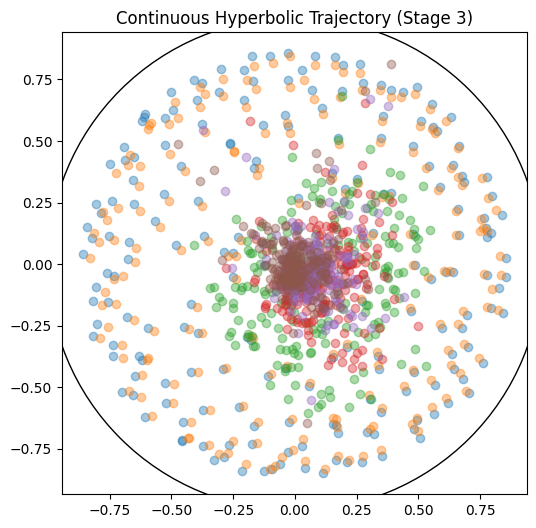

In [ ]:
import matplotlib.pyplot as plt

def visualize_continuous_transition(stage=3):

    data_t = stage_data[stage]
    data_next = stage_data[stage+1]

    G_t = data_t["G"]
    nodes_t = data_t["nodes"]
    nodes_next = data_next["nodes"]

    common = list(set(nodes_t) & set(nodes_next))
    idx_t = [nodes_t.index(n) for n in common]

    z_t = data_t["z"][idx_t]

    degrees = torch.tensor(
        [G_t.degree(n) for n in common],
        dtype=torch.float
    ).to(device)
    log_deg = torch.log(degrees + 1).unsqueeze(1)

    A_t = graph_to_adj(G_t, nodes_t)
    if isinstance(A_t, torch.Tensor):
        A_t = A_t.cpu().numpy()

    A_t_common = torch.tensor(
        A_t[np.ix_(idx_t, idx_t)],
        dtype=torch.float
    ).to(device)

    h_feat = gcn(z_t, A_t_common)

    times = torch.linspace(0.01, 1.0, 5).to(device)

    plt.figure(figsize=(6,6))

    # Plot initial state
    z_init_np = z_t.cpu().numpy()
    plt.scatter(z_init_np[:,0], z_init_np[:,1], alpha=0.4, label="t=0")

    for t_val in times:
        with torch.no_grad():
            t_pair = torch.tensor([0.0, t_val.item()], device=device)

            z_mid = odeint(
                lambda tt, zz: ode_model(tt, zz, log_deg, h_feat),
                z_t,
                t_pair
            )[-1]

            z_mid = manifold.projx(z_mid)
            z_mid = z_mid.cpu().numpy()

            plt.scatter(z_mid[:,0], z_mid[:,1], alpha=0.4)

    circle = plt.Circle((0,0), 1, fill=False)
    plt.gca().add_artist(circle)

    plt.axis("equal")
    plt.title(f"Continuous Hyperbolic Trajectory (Stage {stage})")
    plt.show()

visualize_continuous_transition(3)

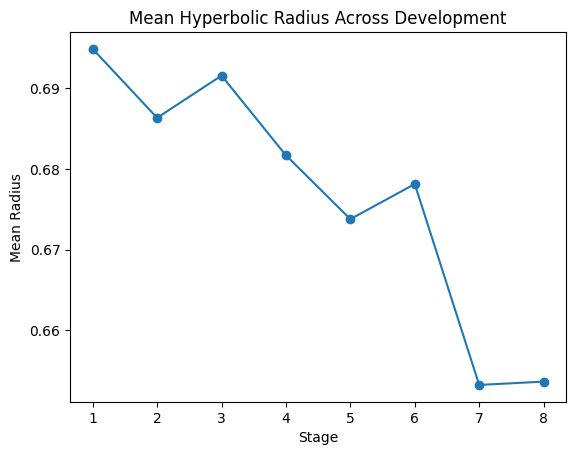

In [ ]:
def plot_radial_growth():

    stage_means = []

    for stage in range(1,9):
        z = stage_data[stage]["z"]
        radii = torch.norm(z, dim=1).cpu().numpy()
        stage_means.append(np.mean(radii))

    plt.plot(range(1,9), stage_means, marker='o')
    plt.xlabel("Stage")
    plt.ylabel("Mean Radius")
    plt.title("Mean Hyperbolic Radius Across Development")
    plt.show()

plot_radial_growth()